In [ ]:
Content
1. Encryption
2. Authetication vs Authorization
    2.2 RBAC
3. All Types of Authentication
    1. Basic Auth
    2. Query Parameter API Key
    3.	Digest Authentication
	4.	Static Header API Key
    5.	Session Cookies (over HTTPS)
	6.	HMAC-Signed Requests
	7.	JWT Access Tokens (short-lived)
    8.	OAuth 2.0 (with PKCE for public clients)
	9.	OpenID Connect (OIDC)
	10.	Mutual TLS (mTLS)
	11.	Kerberos (in enterprise networks)



In [ ]:
# Basics

Concept  | Reversible? | Purpose                          | Examples
---------|-------------|-----------------------------------|-----------------------
Encoding   | Yes (no secret) | Data representation only      | Base64, Hex
Encryption | Yes (with key)  | Confidentiality               | AES-GCM, ChaCha20, RSA
Hashing    | No (one-way)    | Fixed-length fingerprint      | SHA-256, SHA-3, BLAKE3    hashing (no secret key), Fixed Length output
MAC/HMAC   | No (w/o key)    | Integrity + authenticity      | HMAC-SHA256, Poly1305     hashing + secret key (authentication), Fixed Length output


# 1. Encryption

In [ ]:
Encryption transforms readable data (plaintext) into unreadable data (ciphertext) using a key so only authorized parties can get the original back.
Confidentiality: only those with the key can read it.
    - Plaintext --(Encrypt with key)--> Ciphertext 
    - Ciphertext --(Decrypt with key)--> Plaintext

# Types
Type        | Key(s) used                     | Common algos | Typical use
------------|----------------------------------|--------------|----------------------------
Symmetric   | One shared secret key            | AES, ChaCha20| Bulk data at rest/in transit
Asymmetric  | Public key + private key pair    | RSA, ECC     | Key exchange, signatures, small payloads
Hybrid      | Both together                    | AES + RSA/ECC| Real systems (TLS, file sharing, etc.)

1. Symetric encryption (AES)
    - Same key to encrypt and decrypt
    - Very fast, used for bulk data
    - Example: base64 of any random numer.

2. Asymmetric encryption (RSA)
    - Public key (shareable) to encrypt / verify
	- Private key (secret) to decrypt / sign
	- Slower; used for key exchange and identity

# Code
    using var rsa = RSA.Create(2048);
    var privateKey = Convert.ToBase64String(rsa.ExportRSAPrivateKey());
    var publicKey  = Convert.ToBase64String(rsa.ExportRSAPublicKey());


3.  Hybrid encryption (RSA + AES)
    - Hybrid encryption (what you actually use)
	- Use asymmetric crypto to protect a random symmetric session key
    - Used in Web TLS
        - Client: generate AES key → encrypt it with server's PUBLIC key → send
        - Server: decrypt AES key with PRIVATE key → now both use AES for all traffic
    - Flow:
        1) Sender generates random session key K
        2) Encrypt data with K  --> Ciphertext
        3) Encrypt K with recipient's PUBLIC key --> EncryptedK
        4) Send (EncryptedK, Ciphertext)
        5) Recipient uses PRIVATE key to recover K, then decrypts Ciphertext



In [ ]:
# 1. Hashing (SHA-256)
    - Hashing is the one-way; you cannot “decrypt” a hash. Used for checksums, password storage (with salt).
    - Takes input data of any size, but Output length is always same.
    - Output is always the same for same input.
    - Output can not be reversed.
    - It does not require any key/secret.
    - No matter how big or small the input:
    	•	MD5 → 128-bit output (32 hex chars)
    	•	SHA-1 → 160-bit output (40 hex chars)
    	•	SHA-256 → 256-bit output (64 hex chars)
    - Usecase
        - Data Integrity, to check if the data has been modified or not.
            - Ex: If you hash a file and later hash it again, you should get the same hash only if the file hasn’t changed.
        - Fast lookup
            - Store hashed passwords in DB for faster equality checks.
        	- Used in hash tables and indexing.
        - Digital Signatures & Authentication
        	- Combined with keys (HMAC) to verify authenticity.
    - Properties
           - Deterministic → same input always gives same output.
           - Collision resistance → hard to find two different inputs with same hash.
           - Avalanche effect → small input change → completely different output. 
    - Problem: Cannot authenticate who created the hash — if I send you SHA256("Hello"), you can’t be sure it came from me (could be anyone).
    - Purpose:  Data integrity only
    	•	Verify data integrity (data hasn’t been changed). It does not verify who send it.

    - Example:
            Input:  Hello
            Output: 185f8db32271fe25f561a6fc938b2e264306ec304eda518007d1764826381969  (256 bits)
    - Example 2:
            - Message: "userId=123"
            - SHA256(Message) = abc123...
            - Anyone can modify message and recompute SHA256 → no proof of origin.
        
# 2. Encoding
    - Encoding is not security; just representation.
    - Example: Base 64



# 3. HMAC
    - HMAC stands for Hash-based Message Authentication Code.
    - HMAC is NOT just a hash — it’s a hash + secret key.
    - HMAC output is fixed-size and data is non-reversible, so sender has to send raw data as well.
    - Takes input data of any size, but Output length is always same.                
    - It’s a cryptographic technique that uses:
    	1.	A secret key (known to both sender and receiver)
    	2.	A hash function (e.g., SHA-256)

    - Purpose: Data integrity + authenticity
    	•	Verify data integrity (data hasn’t been changed)
    	•	Verify authenticity (came from someone who knows the key)
    - Example (HMAC-SHA256)
        - SecretKey: "superSecret"
        - Message: "userId=123"
        - Signature output = HMAC_SHA256(SecretKey, Message) = xyz789dsfadsfadfadsarbsthwtadvads
            - Only someone with "superSecret" can produce the result
            - If message changes or key changes → signature fails verification.


# Why can't we just use Hash for integrity
     - An attacker could change both the message and the hash, and you have no way to know if it was tampered.

- HMAC fixes this by including a secret key
        - HMAC = hash(key + message + key)

- Working
    1. Sender and receiver share a secret key.
    2. Sender calculates:
            HMAC = Hash( (key ⊕ opad) || Hash( (key ⊕ ipad) || message ) )
       (where opad and ipad are fixed byte patterns, || means concatenation)

	3.	Sender sends [message + HMAC].
	4.	Receiver:
    	•	Calculates HMAC using the same key.
    	•	Compares with received HMAC.
    	•	If they match → message is authentic & unmodified.

- Properties
    - Integrity: Detects if message was changed
    - Authenticity: Proves the message came from someone who knows the key
    - Not encryption: HMAC doesn’t hide data, just authenticates it
    - Key-dependent: Without the key, attacker can’t forge valid tag

- Usecase
	•	API authentication (AWS, Stripe, etc.)
	•	JWT (JSON Web Tokens) — HS256 uses HMAC with SHA-256
	•	TLS (Transport Layer Security) for integrity checks
	•	OAuth 1.0 signatures        

# 2. Authetication vs Authorization

In [ ]:
# Authetication vs Authorization

Aanalogy
Think of it like entering a secured office building:

Authentication: 
    - Showing your ID to the security guard to prove your identity. (JWT, OAuth2 login with Google)
    - Proving identity (username/password, tokens, certificates)
Authorization: 
    - Being allowed access only to certain floors or rooms based on your role. (Ex: Role-Based Access Control (RBAC),)
    - Check whether the user has permission to access specific resource.
    - Granting access to resources after identity is confirmed (roles, scopes, permissions).
        

+--------------------+--------------------------------------------+---------------------------------------------+
| Feature            | Authentication                            | Authorization                               |
+--------------------+--------------------------------------------+---------------------------------------------+
| Definition         | Confirms who the user is                  | Confirms what the user is allowed to do     | 
| Purpose            | Verifies user identity                    | Grants access to resources or actions       |
| Happens When?      | First – before authorization              | After successful authentication             |
| Data Used          | Credentials (e.g., password, biometrics)  | Roles, policies, access control rules       |
| Output             | Identity is verified                      | Permissions are granted or denied           |
| Example            | Login with username and password          | Access to admin panel based on user role    |
| Handled By         | Login systems, Identity Providers (IdP)   | Application logic, ACLs, RBAC/ABAC systems  |
| Visibility         | Visible to the user (login form, OTP)     | Often invisible (denied access, 403 error)  |
+--------------------+--------------------------------------------+---------------------------------------------+
    

### 2.2 RBAC (Authorization)

In [ ]:
# Role-Based Access Control (RBAC) - Backend
    - RBAC means you grant permissions based on a role, and assign users to roles.
    - User ->(has) Roles ->(has) Permissions -> Capabilities

# Components
    1. Define Roles        
    	•	Roles represent a set of permissions.
        •	Example roles: Admin, Manager, User, Guest.        
    2. Permissions Assigned to Roles
        •	Admin → Create, Read, Update, Delete
        •	Guest → Limited Read
    3. Users Assigned to Roles
    	•	Each user gets one or more roles.
    	•	When user logs in, their role(s) are retrieved from DB or identity provider.
    4. Access Decision
    	•	When user tries to access a resource:
        	•	The system checks their roles.
        	•	If the role contains required permission → Access granted.

# Implementation

1. Tables
    a. Users: (1, "alice"), (2, "bob")
    b. Roles: (1, "Admin"), (2, "Manager"), (3, "User")
    c. UserRoles:
        (1, 1) → Alice is Admin
        (2, 3) → Bob is User            

2. When user logins,  Backend generates a JWT token with roles in payload.           
        {
          "sub": "1",
          "username": "alice",
          "roles": ["Admin"]
        }

3. When user requests, perform Middleware for Role Checking
    - In API routes, check if the role is allowed.            

4. If not authorize, then 403 Forbidden.                     

In [ ]:
# Python code Example

######################################################Controller##########################

from fastapi import FastAPI

app = FastAPI()

@app.get("/admin-dashboard", dependencies=[Depends(authorize_roles("Admin"))])
def admin_dashboard():
    return {"message": "Welcome Admin!"}

@app.get("/view-reports", dependencies=[Depends(authorize_roles("Admin", "Manager"))])
def view_reports():
    return {"message": "Reports data here"}

######################################################Service##########################
from fastapi import Depends, HTTPException, status
from fastapi.security import OAuth2PasswordBearer
from jose import JWTError, jwt
from typing import List

# JWT Config (example)
SECRET_KEY = "super_secret_key"
ALGORITHM = "HS256"

# OAuth2 Bearer token extractor
oauth2_scheme = OAuth2PasswordBearer(tokenUrl="token")

# Function to decode JWT and extract roles
def get_current_user_roles(token: str = Depends(oauth2_scheme)) -> List[str]:
    try:
        payload = jwt.decode(token, SECRET_KEY, algorithms=[ALGORITHM])
        roles: List[str] = payload.get("roles", [])
        if not roles:
            raise HTTPException(
                status_code=status.HTTP_403_FORBIDDEN,
                detail="No roles assigned to the user"
            )
        return roles
    except JWTError:
        raise HTTPException(
            status_code=status.HTTP_401_UNAUTHORIZED,
            detail="Invalid authentication token"
        )

# Role checking dependency
def authorize_roles(*allowed_roles: str):
    def role_checker(roles: List[str] = Depends(get_current_user_roles)):
        if not any(role in allowed_roles for role in roles):
            raise HTTPException(
                status_code=status.HTTP_403_FORBIDDEN,
                detail="You do not have permission to access this resource"
            )
    return role_checker
    


In [ ]:
# Role-Based Access Control (RBAC) - Frontend
- Frontend role check is for UX (hidding buttons/ links), not security.

Workflow
1. On Login
    - Fronend receives the JWT token
    - It decodes the token for user roles/ or call an additional api to get roles list.
    - Example:
        {
          "username": "alice",
          "roles": ["Admin"]
        }

2. Conditional Rendering
   - Based on we can do conditional rendering
   - Example:
        {user.roles.includes("Admin") && (
            <button>Manage Users</button>
          )} 

# Example Request Flow
[Login]
   ↓
Backend:
   - Authenticate user
   - Fetch roles from DB
   - Create JWT with roles
   - Send token to frontend
   ↓
Frontend:
   - Store token
   - Read roles from token
   - Show/hide UI based on roles
   ↓
User clicks a feature
   ↓
Backend middleware checks roles → allow/deny        

# 3. All Types of Authentication

In [ ]:
# Security Ranking
+ Rank + Method                      + Risk Without HTTPS       + Revocable? + Typical Use Case                   +
|  1   | Basic Auth                  | High                     | No         | Legacy internal APIs                |
|  2   | API Key in Query            | High                     | Yes        | Old public APIs                      |
|  3   | Digest Auth                 | Medium                   | No         | Rare legacy APIs                     |
|  4   | API Key in Header           | Medium                   | Yes        | Server-to-server APIs                 |
|  5   | Session Cookie (HTTPS)      | Low                      | Yes        | Web apps                              |
|  6   | HMAC-Signed Request         | Low                      | Yes        | Financial APIs, AWS                   |
|  7   | JWT (short-lived)           | Low                      | Partial    | SPAs, mobile APIs                     |
|  8   | OAuth 2.0 + PKCE            | Very Low                 | Yes        | Third-party integrations, SPAs        |
|  9   | OpenID Connect              | Very Low                 | Yes        | SSO, identity providers               |
| 10   | Mutual TLS                  | Very Low                 | Yes        | Internal microservices, fintech APIs  |
| 11   | Kerberos                    | Very Low                 | Yes        | Enterprise AD environments            |

In [ ]:
Weak Security
    1. Basic Auth
    2. Query Parameter API Key

Moderate Security
    3.	Digest Authentication
	4.	Static Header API Key

Stronger Security (With Short-Lived Tokens or Signatures)
	5.	Session Cookies (over HTTPS)
	6.	HMAC-Signed Requests
	7.	JWT Access Tokens (short-lived)

Very Strong Security
	8.	OAuth 2.0 (with PKCE for public clients)
	9.	OpenID Connect (OIDC)
	10.	Mutual TLS (mTLS)
  

In [ ]:
1. Basic Auth
    - Authorization: Basic base64(username:password)
	- the credentials (username:password) are Base64 encoded, not encrypted.
    - Server decodes and validates credentials.
	- Pros: Simple, widely supported.
	- Cons: Credentials sent in every request, must use HTTPS, no session control.
    - Risks
        - Without HTTPS, anyone sniffing network traffic (e.g., on public Wi-Fi) can read credentials.
    - Mitigate Risks
        - Always use HTTPS — this encrypts the entire HTTP request, making it unreadable to a MITM.
     - Question 1: What’s wrong with Basic Authentication?
        - It sends the same Base64-encoded credentials on every request. Without HTTPS, they’re trivially exposed to MITM attacks. Even with HTTPS, repeated credential transmission increases risk — that’s why most modern systems use token-based auth instead

2. Query Parameter API Key
	•	Key visible in URL (logs, browser history, referrer headers).
	•	Easily leaked via shared links or server logs.

3.	Digest Authentication
	•	Avoids sending password in plain text, but outdated.
	•	Weak against modern cryptanalysis if not combined with HTTPS.

4.	Static Header API Key
	•	Safer than query param (hidden from logs), but still static.
	•	If stolen, attacker can use it until it’s rotated.

5.	Session Cookies (over HTTPS)
  	•	Cookies are small key-value pairs stored by the browser to remember information between HTTP requests.
	•	A Session Cookie is a type of cookie that exists only for the duration of the browser session — it’s deleted when the user closes the browser (unless explicitly set with an expiration date).
	•	In web authentication, session cookies often store a session ID that maps to server-side session data (user info, permissions, etc.).  
    - Example: Banking Website flow
        1. User logs in → Bank server validates credentials (often with OTP/2FA).
        2. Server creates a short-lived session in secure memory or DB.
        3. Server sends a Secure + HttpOnly + SameSite session cookie.
        4. All further requests include this cookie over HTTPS.
        5. Server checks:
           - Is the session still valid and device fingure print are same or not.
           - Is IP/device same as when session started?
           - Is request behavior normal? (Fraud detection)
        6. Session expires after short inactivity (e.g., 5–10 minutes).
        7. On logout, session cookie is deleted + server invalidates session.

[User logs in]
   |
   v
Server verifies credentials
   |
   v
Generates session ID (e.g., 4a7d1ed414474e4033ac29ccb8653d9b)
Stores it in server-side session store (DB / in-memory)
   |
   v
Sends Set-Cookie header over HTTPS:
    Set-Cookie: session_id=4a7d1ed4...; HttpOnly; Secure; SameSite=Strict
   |
   v
Browser stores cookie (not accessible to JS if HttpOnly)
   |
[Subsequent requests over HTTPS]
   |
Browser automatically includes:
    Cookie: session_id=4a7d1ed4...
   |
   v
Server looks up session_id → retrieves user data



        

In [ ]:
6.	HMAC-Signed Requests
    •	HMAC signed requests are preferred over JWT in server-to-server communication, public APIs with API keys, and webhook validation where request integrity and authenticity matter more than user identity. JWT is better suited for user authentication and authorization.
    •	Used in APIs where each request is signed with a shared secret, where we want to make sure request comes from a known client and request body is untampered.
    •	It make sure, Does this request come from a client who knows the secret?
    •	Protects Integrity.
	•	Requires secret distribution.
    •	HMAC-signed requests, you still send the plain request data along with the signature. 
    •	Server re-calculate the signature and compare it with the signature received in the request.
            signature = HMAC(secret_key, request_data)

    •	Working
        1. HMAC = Hash-based Message Authentication Code.
        2. You have a shared secret key between client and server.
        3. When the client makes a request, it:
            a. Takes some request data (like path, query, timestamp, body).
            b. Runs it through an HMAC function with the shared secret.
            c. Sends the resulting signature along with the request.
        4. The server recomputes the HMAC and compares.
        5. If they match → request is authentic and untampered.
    - It is always used with HTTPS, if we use HTTP, then
        - HMAC still verifies authenticity and integrity, but the data could still be read by an attacker (confidentiality loss).

    - Usecase
        1. Payment Gateways (Razorpay, paypal): Ensures the request wasn’t altered by an attacker while traveling over the internet.
        2. Webhooks (Github, Slack): Verifies the sender is legitimate and the payload hasn’t been tampered with.




In [ ]:
7. JWT (Json Web Token)
    - A token to claims between two parties (usually client ↔ server) in a stateless way.
    - Client just validate signature and expiry
    - Structure: <Header>.<Payload>.<Signature>
        1. Header
            - {
                  "alg": "HS256",  // Algorithm used for signature
                  "typ": "JWT"
                }

        2. Payload
            - The payload is NOT encrypted by default — it’s only Base64URL encoded.
            - Anyone can decode the token, Security in JWT comes from the signature, which prevents tampering, not from hiding the data.
            - Example:
                                        {
                          "userId": "123",
                          "role": "admin",
                          "exp": 1723201600
                        }
            - Data it contains
                - Registered Claims: iss (issuer), sub (subject), aud (audience), exp (expiry), nbf (not before), iat (issued at), jti (JWT ID — useful for invalidation).
            	- Custom Claims: app-specific data (userId, role, etc.).

        3. Signature
            HMACSHA256(base64UrlEncode(header) + "." + base64UrlEncode(payload), secretKey)

# What is secretKey in JWT
a. For symmetric algorithms  (HS256 / HMACSHA256)
    - A shared private key (string or byte array) known only to the server(s) that sign and verify tokens.
    - Workflow:
        a. HS256 is shorthand for: HMAC + SHA-256 hashing
            - HMAC = “Hash-based Message Authentication Code” — combines a key with data, then hashes it to produce a message authentication code.
            - HMAC always needs:
                	•	A secret key
                	•	A hash function (SHA-256, SHA-1, SHA-512, etc.), SHA-256 = Secure Hash Algorithm (256-bit output).

        b. Verification at receivers end
         	-	Receiver repeats the same HMACSHA256 process with the same secretKey.
        	-	If the signatures match → token is valid.
    - Pros
        ✅ Pros: Fast, simple, one secret to manage.
    - Cons:
        ❌ Cons: If the secret leaks, anyone can both verify and create valid JWTs.                                              
                                               
                                               
                                               
b. For asymmetric algorithms (RS256, ES256, EdDSA)
    - RS256 = RSA + SHA-256.
    - RSA
    	•	Private key (kept secret) → used to sign JWT.
    	•	Public key (shared freely) → used to verify JWT.
    - Verification
    	•	Any service with the public key can verify the token but cannot forge it.        
    - Pros:✅ 
    	•	Public key can be shared openly.
    	•	Safer for distributed systems (only central auth server holds private key).
     - Cons:❌ 
        •	Slower than HMAC.
        •	Requires key pair management.

# C# code
var key = Encoding.UTF8.GetBytes(secretKey);
var token = new JwtSecurityTokenHandler().CreateToken(new SecurityTokenDescriptor
{
    Subject = new ClaimsIdentity(new[] { new Claim("userId", "123") }),
    Expires = DateTime.UtcNow.AddMinutes(15),
    SigningCredentials = new SigningCredentials(
        new SymmetricSecurityKey(key),
        SecurityAlgorithms.HmacSha256 // HS256
    )
});


# Token Expiration and Refresh
JWTs are stateless — they expire naturally after the exp time.

Typical approach:
	•	Access Token (short-lived, e.g., 15 mins)
	•	Refresh Token (longer-lived, e.g., 7–30 days, stored securely)

Refresh flow:
	1.	Client’s access token expires.
	2.	Client sends refresh token to /refresh endpoint.
	3.	Server verifies refresh token (often stored in DB or Redis).
	4.	Server issues new access token (and possibly a new refresh token).
	5.	Old refresh token can be invalidated to prevent replay.

# How Stateless Refresh Token Works (Approach-1 with Redis)
 1.	Login:
	•	Server issues access token (short expiry, e.g., 15 min).
	•	Server issues refresh token (long expiry, e.g., 7 days). stored in redis
	•	Both are signed JWTs.
2.	Refresh:
	•	Client sends refresh token to /refresh.
	•	Server verifies:
	•	Signature is valid (secret or public key matches).
	•	exp claim hasn’t expired.
	•	iss, aud, sub claims are correct.
	•	If valid → issue new access token (and possibly new refresh token).
3.	Revocation Problem If we do not store the refresh token in cache:
	•	If refresh token is stolen, it’s valid until expiry — no way to revoke early.

# How Stateless Refresh Token Works (Approach-2 without Redis)
1. In refresh token payload, add
    - iat (issued at)
    - exp (expiry)
2. On refresh request (/refresh)
    - Verify signature (HMAC, RSA)
    - Payload Check
        - exp: token is still within its validity period
        - if yes, and (now - iat) > 10 days, then reject and force re-login.
        - else, issue a new token



# Invalidating JWT
  - Since JWT is stateless, you cannot just “delete” it from the server 
  - Rotate secrets — invalidate all tokens signed with old key.

# Generating Multiple JWTs from Same Credentials
If a client logs in multiple times from different devices:
	•	By default, each login generates a new JWT — all remain valid until expiry.
	•	Risks: If tokens are stolen, attacker can still use them.
	•	Solutions:
    	•	Track active sessions in DB (map jti → user).
    	•	Invalidate all sessions on logout/change password.
    	•	Limit number of active tokens per user.      

#Verify Token
header  = { "alg": "HS256", "typ": "JWT" }
payload = { "sub": "123", "exp": 1699999999, "role": "admin" }
signature = HMACSHA256(base64(header) + "." + base64(payload), secret)

# FAQ
1. If JWT contains the user’s role, and the role changes in DB, will the JWT reflect it immediately?
    - No. JWTs are self-contained and immutable.
    - Sol: check role from DB every time instead of trusting token claim, or after min 15 when token expires, the new token will be generate with the updated role.

In [ ]:
JWT (Statefull)
    - using JTI: (JWT ID) is a unique identifier for each token instance.
    - {
          "sub": "user123",
          "jti": "5e9b62f0-2c2c-4d54-9557-23c2b1a3a0e4",
          "exp": 1723522800
         
    - In Redis, you save:
        jti:5e9b62f0-2c2c-4d54-9557-23c2b1a3a0e4 → { userId: user12, device: Chrome, exp: 1723522800 }
    - UseCase
    	•	Revocation → On logout or password change, delete this jti key → token is instantly invalid.
    	•	Session management → You can see all active tokens for a user by querying all jti keys for that userId.
    	•	Limit concurrent sessions → If user already has 3 active tokens, deny issuing a new one.
    	•	Audit → Track device/IP used to issue the token.

    - Token Verification:
        - When a request comes in with a refresh token:
        	1.	Decode the JWT (don’t trust claims yet).
        	2.	Verify signature & expiry.
        	3.	Extract jti.
        	4.	Look up jti in Redis:
            	•	Exists? → Token still valid.
            	•	Missing? → Token revoked → reject request.
                                                       

In [ ]:
8. OAuth 2 (Server to Server)
    - Client Credentials Grant.
    - Machine-to-machine calls: microservices, batch jobs, backend → external API.
    - No user context; the client acts as itself.
    - Both sides are confidential clients and can keep secrets/keys.
    - Refresh Token
        - The client is a confidential server that can safely store its client ID and client secret (or private key).
        - When the access token expires, the server can directly request a new token using the same credentials.
        - Refresh tokens are mainly designed for public clients (mobile apps, SPAs) that cannot safely store secrets — so they can get new access tokens without user interaction.

    - Response:
        {
          "access_token": "eyJhbGciOiJSUzI1NiIsInR5cCI6IkpXVCJ9...",
          "token_type": "Bearer",
          "expires_in": 900,
          "scope": "api.read"
        }


# Working
    1) Service A (client) is provisioned at AS:
       client_id, client_secret (or certificate/private key)
    
    2) Service A requests a token:
       POST /token  grant_type=client_credentials
                    client_id=<id>
                    client_secret=<secret>
                    scope=api.read api.write (optional)
                    audience=https://api.example.com (if supported)
    
    3) AS issues access_token (usually JWT) with 'sub'=client_id, scopes, aud.
    
    4) Service A calls Service B’s API with:
       Authorization: Bearer <access_token>
    
    5) Service B validates token (iss, aud, exp, signature) and applies scopes.


In [ ]:
8.	OAuth 2.0 (Web to Server)
    - Usecase: One 3rd party (Cred) want to access our data (emails) directly from google, Without sharing our username/ passwords to Cred.
            - Cred will have access only to those emails which are granted permission.
            - Access token provided to Cred will have a expiry time and can be revoke by google/ owner at any time.
            - It also provides a refresh token, so a new token can be generated without our explicite permissions.

OAuth 2.0 is an authorization framework — it lets an application get access to a user’s resources on another service without handling the user’s password directly.

# Parties Involved
    - Resource Owner (User)
    - Client (Your app)        -> wants access on behalf of user or itself (App: Cred)
    - Authorization Server     -> iIssues tokens after authenticating the user (e.g., Google OAuth server) (App: Google)
    - Resource Server (API)    -> The API hosting the user data (e.g., Google Drive API). It validates tokens, serves data (App: Gmail)

# Working
1. User clicks on Loging with Provider button.
    - The client (web app) redirects the user’s browser to the Authorization Server:
    - Request
        GET https://auth.example.com/authorize?
          response_type=code   # we want an authorization code.
          &client_id=CLIENT_ID
          &redirect_uri=https://app.example.com/callback
          &scope=read_profile email
          &state=RANDOM_STRING.  # CSRF protection; a random string.

2. User Log-in and grants permission
    - The AS authenticates the user and asks for consent.
    - If approved, AS redirects back to the client with an authorization code:
    - Response:
            GET https://app.example.com/callback?
              code=AUTH_CODE
              &state=RANDOM_STRING

3: Client exchanges code for an access token (Server to Server)
    - The web app server makes a POST request to the token endpoint:
    - Request
            POST https://auth.example.com/token
            Content-Type: application/x-www-form-urlencoded
            
            grant_type=authorization_code
            &code=AUTH_CODE # Received in the above response
            &redirect_uri=https://app.example.com/callback
            &client_id=CLIENT_ID
            &client_secret=CLIENT_SECRET
    
    - Request Parameters
        1. client_id/ client_secret: 
            - client_id & client_secret are app credentials, not user credentials.
            - These values are the same for all users of this client application.
            - Without these credentials of Client app, anyone who gets the above code could exchange it for an access token — that would be a huge security hole.

    - Response:
            {
              "access_token": "eyJhbGciOiJIUzI1...",
              "token_type": "Bearer",
              "expires_in": 3600,
              "refresh_token": "def50200..."
            }

4. Web app calls Resource Server
    - Server makes an API request including the access token in the header:                                                                                                   
    - Resource server validates the token (signature, expiry, audience, scopes) and returns data (like emails in case of Cred).
    - Request
            GET https://api.example.com/user/profile
            Authorization: Bearer eyJhbGciOiJIUzI1...

5. Refresh Token
    - Web server uses refresh token to request a new access token
    - Long-lived access without repeated user login.
    - Request
            POST /token
            grant_type=refresh_token
            &refresh_token=REFRESH_TOKEN
            &client_id=CLIENT_ID
            &client_secret=CLIENT_SECRET



# Security Checks in Web OAuth
    1. HTTPS only:	Protect tokens in transit
    2. CSRF protection (state):	Prevent cross-site request forgery
    3. Short-lived access tokens:	Limit exposure if stolen
    4. Refresh token stored server-side:	Prevent JS/browser leaks
    5. Exact redirect_uri matching:	Prevent authorization code leakage
    6. Rotate client secret periodically:	Protect confidential clients



                                                                                                       
User Browser             Web App (Client)            Authorization Server
-----------               ---------------            ---------------------
   |                            |                               |
   |---[GET /authorize]-------->|                               |
   |                            |---[Redirect with code]-------->|
   |<--User approves/login------|                               |
   |                            |                               |
   |                            |---[POST /token + client_secret]-->|
   |                            |<--access_token + refresh_token--|
   |                            |                               |
   |---[API call w/ access_token]------------------------------->|
   |                            |                               |
   |<--------------------------Data from Resource Server---------|


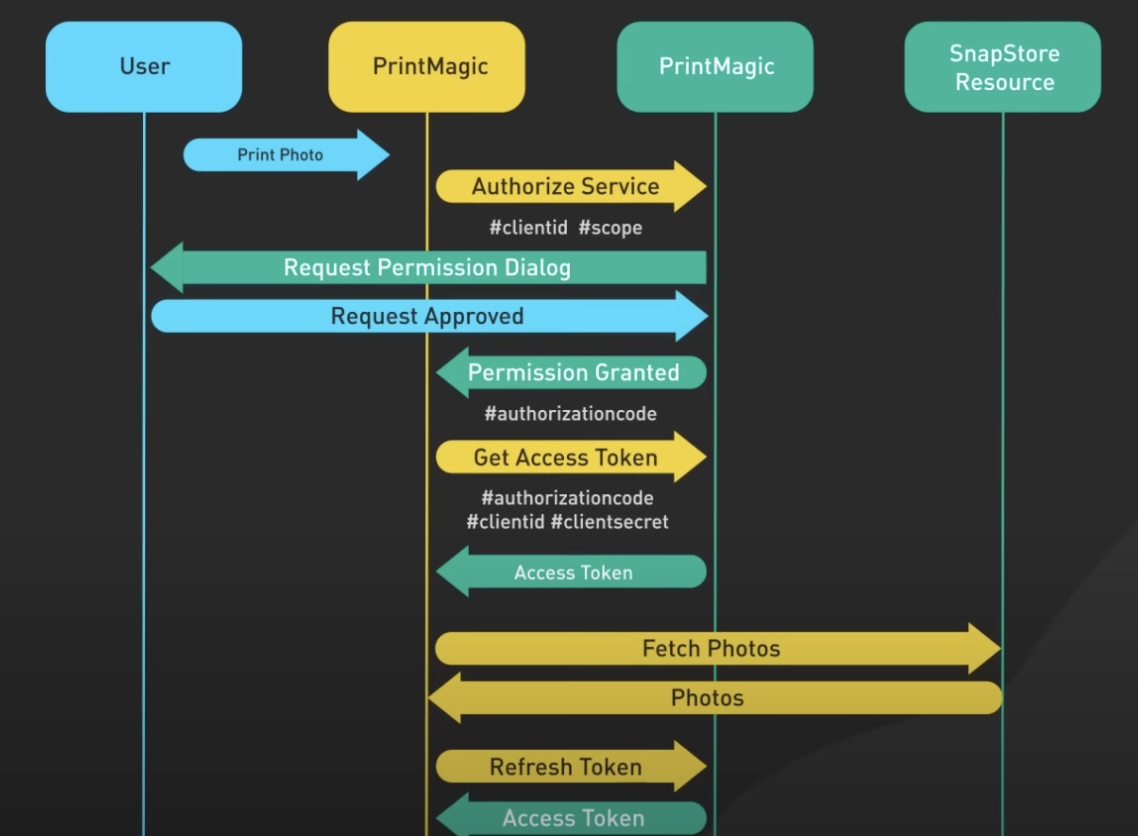

In [ ]:
1. OAuth Without PKCE (Confidential Client)
    - When to use: Server-side web apps that can safely store a client secret.
    - same as above, when request has client_secret.
    - Problem it solves: Prevents authorization code interception attacks because only a server with the client_secret can exchange the code.

2. OAuth With PKCE (Public Client)
    - When to use: Public clients that cannot safely store secrets, e.g., mobile apps or SPA.
    - Request parameter changes, Instead of client_secret, it has  2 Extra PKCE parameters
        - code_verifier → random high-entropy string generated by the client.
        - code_challenge → BASE64URL(SHA256(code_verifier)) sent to AS.
        - Example: 
            code_verifier = "random_43-128_chars"
            code_challenge = BASE64URL(SHA256(code_verifier))
    - Working
        1. Client Generates PKCE values
        2. Broweser redirects user to AS, with the following request
                GET /authorize?response_type=code
                    &client_id=PUBLIC_CLIENT_ID
                    &redirect_uri=https://app.example.com/callback
                    &scope=read_profile email
                    &state=RANDOM_STRING
                    &code_challenge=CODE_CHALLENGE
                    &code_challenge_method=S256

        3. Authorization Sever redirects back with authorization code:
                GET /callback?code=AUTH_CODE&state=RANDOM_STRING
        4. Client exchanges code for access token
                POST /token
                    grant_type=authorization_code
                    code=AUTH_CODE
                    redirect_uri=https://app.example.com/callback
                    client_id=PUBLIC_CLIENT_ID
                    code_verifier=CODE_VERIFIER
        5. Authorization Server verifies with: 
            - SHA256(code_verifier) == code_challenge
        6. Authorization Server returns the access_token

    - Problems it solved
            - Prevents authorization code interception attacks without needing a client secret.
            - Even if an attacker steals the authorization code, they cannot redeem it without the code_verifier.

Note:
    - Without PKCE → rely on client_secret; safe for server apps.
    - With PKCE → use code_verifier instead of client_secret; necessary for public clients.

In [ ]:
9.	OpenID Connect (OIDC)
    - OIDC is basically OAuth 2.0 + ID Token (for authentication)
    - OIDC is an authentication layer built on top of OAuth 2.0.
    - While OAuth 2.0 is mainly for authorization (access to resources), OIDC provides a standardized way to authenticate users and get their identity.
    - It uses JSON Web Tokens (JWT) called ID Tokens to convey information about the user.
    
    OIDC = “Who is the user?”    
    OAuth 2.0 = “Can I access this resource?”

    - Purpose of OIDC
        1. User authentication: Confirms the user’s identity to the client application.
        2. Standardized identity information: Provides claims like sub (user ID), name, email, picture, etc.
        3. Interoperability: Works with multiple identity providers (Google, Microsoft, Okta, Auth0) using the same protocol.
        4. Single Sign-On (SSO): Enables seamless login across apps using the same identity provider.
    - Problem it solves
        1. OAuth 2.0 does not tell user identity:	It Provides ID Token with standardized claims
        2. Need for user authentication:	Enables apps to verify the user without handling passwords
        3. SSO across apps: Allows single sign-on with consistent identity information
    - Usecase:
        - Logging in users to web/mobile apps without storing passwords.
        - Single Sign-On across multiple apps in an organization.
        - Apps that need both identity + API access (OAuth access token + ID token).

Working:
    - Everything else is identical to OAuth 2.0: authorization code flow, token exchange, refresh token mechanics.
    - The only addition is:
        a. scope=openid in the authorization request.
                    GET /authorize?
                      response_type=code
                      &client_id=CLIENT_ID
                      &redirect_uri=https://app.example.com/callback
                      &scope=openid profile email
                      &state=RANDOM_STRING

        b. id_token in the token response (and optionally in the implicit/hybrid flows).
                {
                  "access_token": "eyJhbGciOiJIUzI1...",
                  "id_token": "eyJhbGciOiJSUzI1NiIsInR5cCI6IkpXVCJ9...",
                  "refresh_token": "def50200..."
                }
    - The ID Token is a JWT that contains user identity claims
        - sub: Unique user Id
        - iss: Issuer
        - aud: audience, client
        - exp: expiry
        - Optional: email, name, picture.


In [ ]:
Single Sign-on (SSO) 
    - Single Sign-On (SSO) allows a user to log in once and access multiple applications/systems without re-entering credentials each time.
    - It works by having a central identity provider (IdP) that handles authentication, and applications trust it.
    - Components
        •	User — person trying to log in.
    	•	Application / Service Provider (SP) — the app the user wants to access.
    	•	Identity Provider (IdP) — central login system (e.g., Okta, Azure AD, Google).
    - Typical Protocols: SAML, OAuth 2.0, OpenID Connect.
    - Pros/ Usecase
        •	Authentication happens at IdP, not each app.
        •	Apps trust IdP’s tokens via shared keys or certificates.
    - Cons:
        Risks: If IdP is compromised, all connected apps are at risk.

# Work Flow
Step-by-Step Flow (Example: OpenID Connect / OAuth2 style)
	1.	User tries to access App A → App detects user is not logged in.
	2.	App redirects user to IdP (Identity Provider login page).
	3.	User enters credentials (username/password, MFA, etc.) at IdP.
	4.	IdP authenticates the user (checks DB, AD, etc.).
	5.	IdP generates a signed token (e.g., JWT) containing user identity & roles.
	6.	IdP redirects back to App A with the token.
	7.	App A validates token (signature, expiry, issuer).
	8.	User is granted access without entering credentials again.
	9.	When user goes to App B:
    	•	App B checks for token or active IdP session.
    	•	If found, skips login → grants access.        

In [ ]:
10. Mutual Transport Layer Security (mTLS) (Server to Server)
    - HTTPs
        - Standard TLS/HTTPS secures communication from client to server.
        - when a browser want to connect to a server, the server provides a certificate to the browser.
        - Browser validates the cerificate and confirm the server is authentic. (XO95 digital certificate)
        - Standard TLS ensures server authenticity but not client authenticity.
        - How does browser validate the certificate  
            1. When you visit a website (https://example.com)
            2. browser Receive the server certificate
                - The server sends its X.509 certificate (public key + identity info + signature chain).
                - It may also send the intermediate certificates that link it to a trusted root CA.
            3. Check validity period
                - Browser verifies that the certificate’s Not Before and Not After dates are valid (not expired).
                - If expired → browser shows “certificate expired” warning.
            4. Check certificate chain
                - Certificates are issued by a Certificate Authority (CA).
                - Browser builds a chain of trust from the server certificate → intermediate CA → root CA.
                - Browser has a pre-installed list of trusted root CAs.
                - If the chain ends at a trusted root CA → chain is valid.
                - If any certificate in the chain is invalid → warning is shown.
            5. Verify digital signature
                - Each certificate in the chain is digitally signed by the issuer (CA).
                - Browser uses the issuer’s public key to verify the signature.
                - This ensures the certificate hasn’t been tampered with.
            6. Establish TLS connection
                - If all checks pass:
                    - Browser trusts the server certificate.
                    - Proceeds to TLS key exchange to establish an encrypted session.
                                                          
    - mTLS        
        - mTLS = identity + encryption + zero trust
        - Mutual TLS extends TLS so that both the client and server authenticate each other using certificates.
        - To call an API using mTLS, the client sends its certificate and private key along with the request, while also verifying the server’s certificate using a trusted CA, enabling mutual authentication before establishing a secure connection.
            
        - Purpose
            - Standard TLS ensures server authenticity but not client authenticity.
            - mTLS ensures:
                - Server knows the client is legitimate → prevents unauthorized clients from connecting.
                - Data in transit is encrypted.s
                - Stronger machine-to-machine authentication than passwords or API keys.

        - Use cases:
            - Microservices calling each other internally.
            - Server-to-server APIs in sensitive environments (finance, banking, healthcare).
        - Working
            1. Client connects to server: "Hello" (ClientHello)
            2. Server responds with its certificate (ServerHello + cert)
                - Server proves identity
            3. Client verifies server certificate
            4. Server requests client certificate (mTLS specific step)
            5. Client sends its certificate + proves ownership of private key
            6. Server verifies client certificate
            7. TLS session is established only if both verify each other
            8. Encrypted data exchange begins
                               

In [ ]:
import requests

url = "https://service-b/api/data"

data = {
    "name": "Sourav",
    "message": "Hello from Service A"
}

response = requests.post(
    url,
    json=data,
    cert=("client.crt", "client.key"),  # client certificate
    verify="ca.crt"                     # verify server, enables server validation
)

print(response.status_code)
print(response.text)

Steps:
    1. Service A → sends POST request with client cert
    2. Service B → sends server cert
    3. Service A → verifies server (CA)
    4. Service B → verifies client (CA)
    5. Secure connection established
    6. JSON data sent
    7. Response returned

Pros:
TLS handshake ensures:
    ✔ Both services are trusted
    ✔ Communication is encrypted
    ✔ No unauthorized service can call API



10. Mutual TLS (mTLS) (Server to Server)

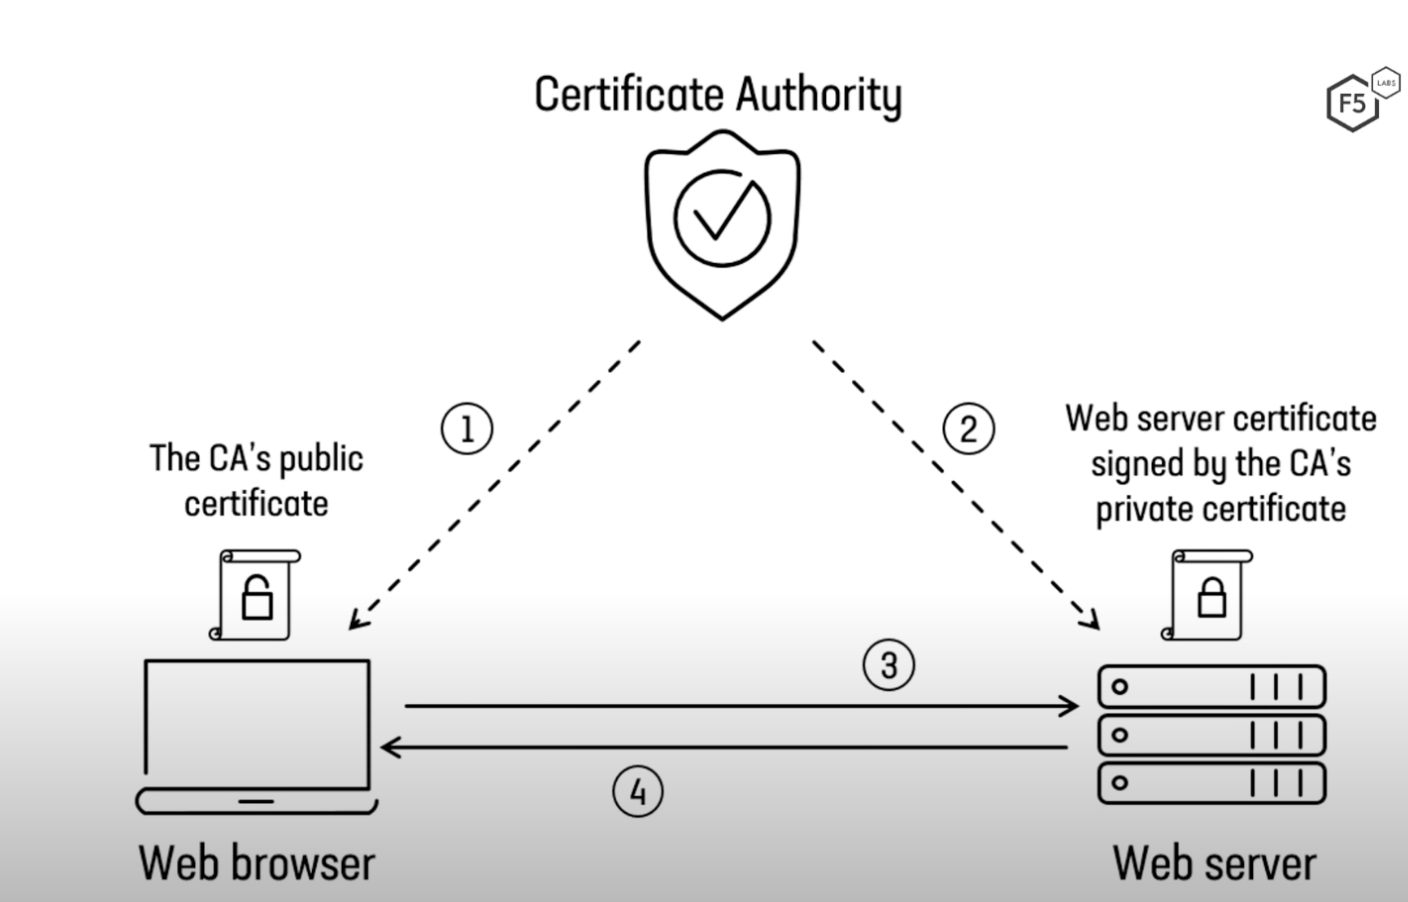
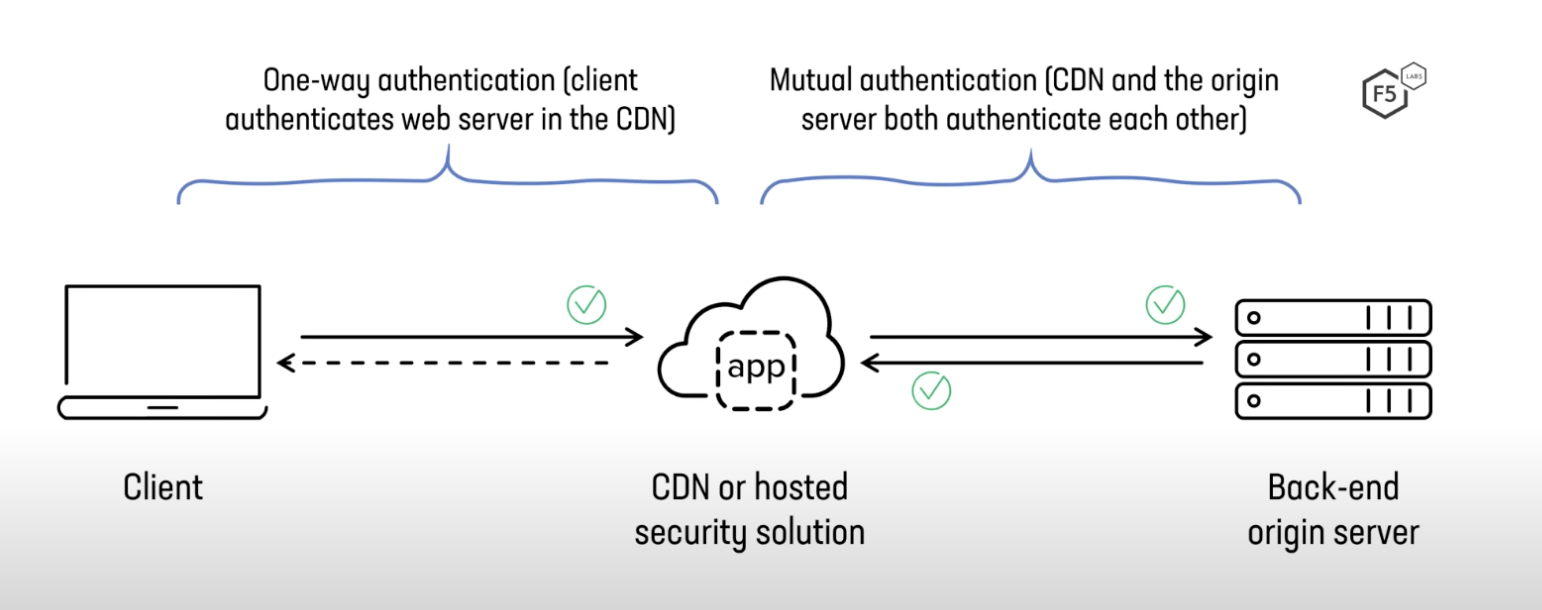

In [ ]:
11. Kerberos (in enterprise networks)
    - Kerberos is a network authentication protocol designed for secure user authentication in a client-server environment.
    - It uses tickets instead of passwords to authenticate.
    - Use cases:
        - Enterprise Windows networks (Active Directory).
        - Linux/Unix networks using Kerberos for authentication (e.g., Hadoop, SQL Server, SSH).
        - SSO across multiple services in a corporate network. 
    - Purpose
        - Authenticate users without sending passwords over the network.
        - Prevent replay attacks using time-limited tickets.
        - Allow single sign-on (SSO) to multiple services in a network.
    - Working
        1. User logs into client machine with username/password
           -> Client authenticates with Key Distribution Center (KDC)
           -> KDC gives Ticket Granting Ticket (TGT), encrypted using user's key
        
        2. Client wants access to a service
           -> Client sends TGT to KDC, requests Service Ticket for target service
        
        3. KDC issues Service Ticket
           -> Encrypted with service's secret key, client can present it to service
        
        4. Client sends Service Ticket to server
           -> Server decrypts ticket, verifies authenticity
           -> If valid, server grants access
        
        5. Session is established
           -> No password is sent over the network